<center>
<a href="http://www.insa-toulouse.fr/" ><img src="http://www.math.univ-toulouse.fr/~besse/Wikistat/Images/logo-insa.jpg" style="float:left; max-width: 120px; display: inline" alt="INSA"/></a> 

</center>

# Projet Machine Learning — 4MA 2025-2026
## Prédiction du Risque de Maladie Cardiovasculaire
### INSA Toulouse
---

**Jeu de données** : *Cardiovascular Disease Risk Prediction Dataset* : 15 000 patients   
**Langage** : Python   
**Objectifs** :
- Partie 1 : Prédiction de `Heart_Disease_Risk` 
- Partie 2 : Prédiction de `Cholesterol_LDL` 

> Ce notebook vient compléter l'étude réalisée en R. Les conclusions sont comparables, > mais Python offre une exécution plus rapide, notamment pour la validation croisée.

### 0. Importation des bibliothèques et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import time

randomseed = 111 

In [2]:
df = pd.read_csv("healthcare_synthetic_data.csv")
print(df.shape)
df.head()


(15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [3]:
# Vérification des types de données et des valeurs manquantes
print("Types des variables :")
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isnull().sum())

# Prétraitement des données
df = df.drop(columns=["Patient_ID"])
for col in ["Gender", "Smoking_Status", "Family_History", "Heart_Disease_Risk"]:
    df[col] = pd.Categorical(df[col], ordered=False)
df["Alcohol_Consumption"] = pd.Categorical(
    df["Alcohol_Consumption"], categories=[0, 1, 2], ordered=True)
df["Physical_Activity_Level"] = pd.Categorical(
    df["Physical_Activity_Level"], categories=[0, 1, 2, 3], ordered=True)
print(df.dtypes)
df.describe()


Types des variables :
Patient_ID                  object
Age                          int64
Gender                       int64
Height_cm                  float64
Weight_kg                  float64
BMI                        float64
Systolic_BP                  int64
Diastolic_BP                 int64
Cholesterol_Total            int64
Cholesterol_LDL              int64
Cholesterol_HDL              int64
Fasting_Blood_Sugar          int64
Smoking_Status               int64
Alcohol_Consumption          int64
Physical_Activity_Level      int64
Family_History               int64
Stress_Level                 int64
Sleep_Hours                  int64
Heart_Disease_Risk           int64
dtype: object

Valeurs manquantes :
Patient_ID                 0
Age                        0
Gender                     0
Height_cm                  0
Weight_kg                  0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Cholesterol_Total          0
Cholesterol_LDL 

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200,5.503667,6.506067
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355,2.874277,1.212626
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000,1.000000,4.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000,3.000000,6.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000,5.500000,7.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000,8.000000,7.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000,10.000000,10.000000


### 1. Prédiction du risque d’accident cardiaque

In [4]:
X = df.drop(columns=["Heart_Disease_Risk"])
y = df["Heart_Disease_Risk"]

In [5]:
# Division en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=randomseed)

# Vérification des tailles des ensembles
print("Taille apprentissage :", X_train.shape[0])
print("Taille test :", X_test.shape[0])

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Taille apprentissage : 12000
Taille test : 3000


Cette étape est essentielle car elle permet d'estimer les performances réelles du modèle sur des données qu'il n'a jamais vues durant l'apprentissage. Sans cette séparation, le modèle pourrait simplement mémoriser les données d'entraînement et afficher de bonnes performances sans pour autant être capable de généraliser à de nouveaux patients.On retient 20% des données pour le test, soit 3 000 patients.

#### 1.1 Modèle Linéaire Généralisé

##### 1.1.1 Sans pénalisation

Accuracy Train : 0.7361
Accuracy Test  : 0.7530

Matrice de confusion (Test) :
[[1426  335]
 [ 406  833]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1761
           1       0.71      0.67      0.69      1239

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000



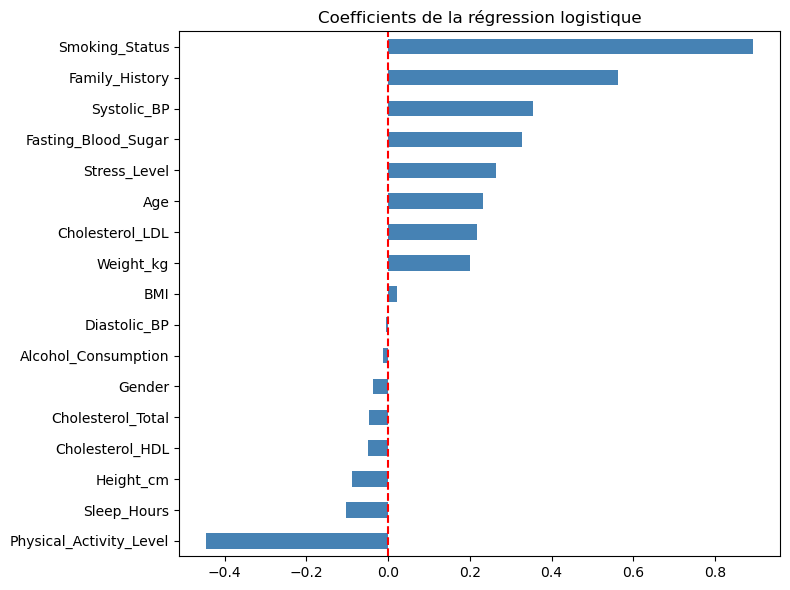

In [6]:
log_reg = LogisticRegression(penalty=None, max_iter=1000, random_state=randomseed)
log_reg.fit(X_train_scaled, y_train)

# Prédictions
y_pred_train = log_reg.predict(X_train_scaled)
y_pred_test  = log_reg.predict(X_test_scaled)

# Évaluation des performances
print(f"Accuracy Train : {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Accuracy Test  : {accuracy_score(y_test, y_pred_test):.4f}")
print("\nMatrice de confusion (Test) :")
print(confusion_matrix(y_test, y_pred_test))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test))

# Visualisation des coefficients
coef = pd.Series(log_reg.coef_[0], index=X.columns)
coef.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title("Coefficients de la régression logistique")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()


##### 1.1.2 Lasso L1

C optimal : 21.5443
Accuracy Train : 0.7361
Accuracy Test  : 0.7530

Matrice de confusion (Test) :
[[1426  335]
 [ 406  833]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1761
           1       0.71      0.67      0.69      1239

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000


Variables éliminées (coef = 0) : 0
Variables conservées : 17


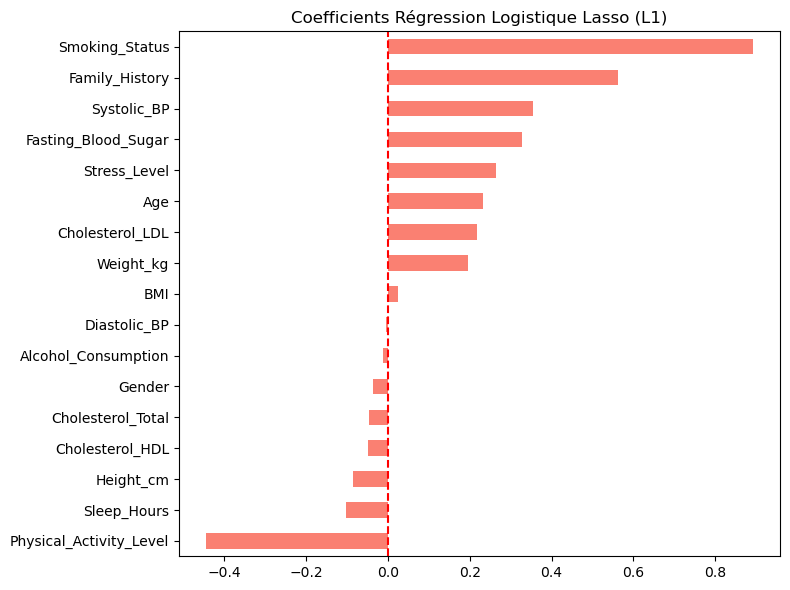

In [7]:
from sklearn.linear_model import LogisticRegressionCV

# ── Régression Logistique avec pénalisation L1 ────────────────
# On utilise LogisticRegressionCV pour optimiser C par validation croisée
# C = 1/lambda (plus C est petit, plus la pénalisation est forte)
log_lasso = LogisticRegressionCV(
    penalty='l1',
    solver='saga',
    cv=10,
    max_iter=1000,
    random_state=randomseed
)
log_lasso.fit(X_train_scaled, y_train)

# ── C optimal trouvé par validation croisée ───────────────────
print(f"C optimal : {log_lasso.C_[0]:.4f}")

# ── Prédictions ───────────────────────────────────────────────
y_pred_train_lasso = log_lasso.predict(X_train_scaled)
y_pred_test_lasso  = log_lasso.predict(X_test_scaled)

# ── Performances ──────────────────────────────────────────────
print(f"Accuracy Train : {accuracy_score(y_train, y_pred_train_lasso):.4f}")
print(f"Accuracy Test  : {accuracy_score(y_test, y_pred_test_lasso):.4f}")
print("\nMatrice de confusion (Test) :")
print(confusion_matrix(y_test, y_pred_test_lasso))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test_lasso))

# ── Coefficients (variables sélectionnées) ────────────────────
coef_lasso = pd.Series(log_lasso.coef_[0], index=X.columns)
print(f"\nVariables éliminées (coef = 0) : {sum(coef_lasso == 0)}")
print(f"Variables conservées : {sum(coef_lasso != 0)}")

coef_lasso.sort_values().plot(kind='barh', figsize=(8, 6), color='salmon')
plt.title("Coefficients Régression Logistique Lasso (L1)")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

##### 1.1.3 Ridge L2

In [ ]:
# ── Régression Logistique avec pénalisation L2 ────────────────
# L2 est le penalty par défaut de LogisticRegressionCV
log_ridge = LogisticRegressionCV(
    penalty='l2',
    solver='saga',
    cv=10,
    max_iter=1000,
    random_state=randomseed
)
log_ridge.fit(X_train_scaled, y_train)

# ── C optimal trouvé par validation croisée ───────────────────
print(f"C optimal : {log_ridge.C_[0]:.4f}")

# ── Prédictions ───────────────────────────────────────────────
y_pred_train_ridge = log_ridge.predict(X_train_scaled)
y_pred_test_ridge  = log_ridge.predict(X_test_scaled)

# ── Performances ──────────────────────────────────────────────
print(f"Accuracy Train : {accuracy_score(y_train, y_pred_train_ridge):.4f}")
print(f"Accuracy Test  : {accuracy_score(y_test, y_pred_test_ridge):.4f}")
print("\nMatrice de confusion (Test) :")
print(confusion_matrix(y_test, y_pred_test_ridge))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test_ridge))

# ── Coefficients ────────────────

C optimal : 2.7826
Accuracy Train : 0.7361
Accuracy Test  : 0.7530

Matrice de confusion (Test) :
[[1426  335]
 [ 406  833]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1761
           1       0.71      0.67      0.69      1239

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000



In [ ]:
# ── Tableau comparatif des 3 modèles ─────────────────────────
resultats_logit = pd.DataFrame({
    "Modèle": [
        "Logistique (sans pénalisation)",
        "Logistique Lasso (L1)",
        "Logistique Ridge (L2)"
    ],
    "C optimal": ["-", "21.5443", "2.7826"],
    "Accuracy Train": [0.7361, 0.7361, 0.7361],
    "Accuracy Test":  [0.7530, 0.7530, 0.7530],
    "F1-score (classe 1)": [0.69, 0.69, 0.69],
    "Variables éliminées": ["-", "0", "-"]
})

print(resultats_logit.to_string(index=False))

                        Modèle C optimal  Accuracy Train  Accuracy Test  F1-score (classe 1) Variables éliminées
Logistique (sans pénalisation)         -          0.7361          0.753                 0.69                   -
         Logistique Lasso (L1)   21.5443          0.7361          0.753                 0.69                   0
         Logistique Ridge (L2)    2.7826          0.7361          0.753                 0.69                   -


#### 1.2 Arbre de Décision Optimal (CART)

Meilleur score (Accuracy) = 0.706750, Meilleur paramètre = {'max_depth': 5}
Erreur de prévision sur le test : 0.269000

Matrice de confusion CART :
 Observé     0    1
Prédit            
0        1452  498
1         309  741


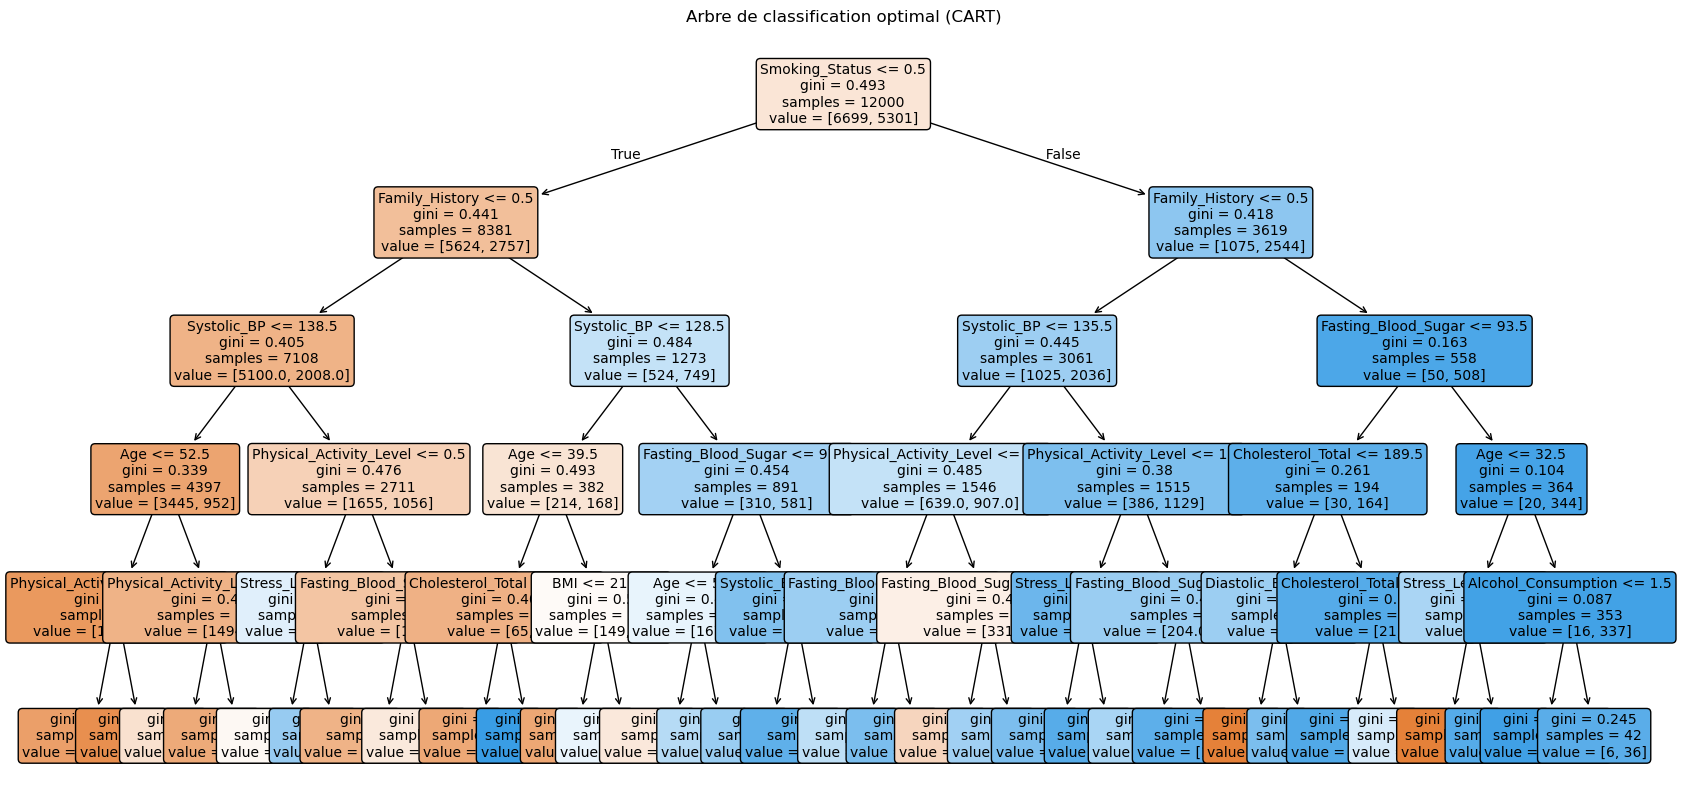

In [8]:

# Optimisation de la profondeur de l'arbre (comme dans l'Épisode 3 du TP)
# On teste des profondeurs de 2 à 10
param = [{"max_depth": list(range(2, 10))}]
tree = GridSearchCV(DecisionTreeClassifier(random_state=randomseed), param, cv=5, n_jobs=-1)
treeOpt = tree.fit(X_train, y_train)

# Paramètre optimal
print("Meilleur score (Accuracy) = %f, Meilleur paramètre = %s" % (treeOpt.best_score_, treeOpt.best_params_))

# Estimation de l'erreur de prévision sur le test (façon TP)
print("Erreur de prévision sur le test : %f" % (1 - treeOpt.score(X_test, y_test)))

# Prévision de l'échantillon test
y_chap_tree = treeOpt.predict(X_test)

# Matrice de confusion avec crosstab (façon TP)
table_tree = pd.crosstab(y_chap_tree, y_test, rownames=['Prédit'], colnames=['Observé'])
print("\nMatrice de confusion CART :\n", table_tree)

# Affichage de l'arbre optimal
plt.figure(figsize=(20, 10))
# On utilise best_estimator_ pour tracer l'arbre qui a gagné le GridSearch
plot_tree(treeOpt.best_estimator_, feature_names=X_train.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Arbre de classification optimal (CART)")
plt.show()

« Dans cette partie, nous avons cherché à modéliser le risque de maladie cardiovasculaire à l'aide d'un arbre de décision (CART). Contrairement au modèle logistique, l'avantage recherché ici est la lisibilité : l'arbre fournit des règles de décision claires, très appréciées dans le domaine médical.

1. Optimisation de la complexité et Performance globale
Pour éviter le problème classique de surapprentissage (overfitting) des arbres de décision, nous avons optimisé la profondeur maximale de l'arbre par validation croisée (GridSearchCV).

L'algorithme a retenu une profondeur optimale de 5 (max_depth: 5). Un arbre plus profond aurait mémorisé le bruit des données d'entraînement, tandis qu'un arbre plus petit aurait été trop simpliste.

Avec ce paramétrage, le modèle atteint une Accuracy de validation de 70.6%.

Sur notre jeu de test, l'erreur de prévision est de 0.269, ce qui correspond à une exactitude (Accuracy) de 73.1%.

Comparaison : On remarque que cette performance (73.1%) est légèrement inférieure à celle de notre modèle de régression logistique (75.30%). Comme stipulé dans notre cours, c'est un comportement normal : un arbre de décision seul est un modèle à forte variance dont la précision prédictive brute est souvent en retrait par rapport à d'autres méthodes.

2. Analyse clinique (Matrice de Confusion)
Au-delà du score global, l'analyse de la matrice de confusion révèle le comportement de notre arbre sur le terrain médical :

1452 Vrais Négatifs : Les patients sains correctement classés comme n'étant pas à risque.

741 Vrais Positifs : Les patients à risque correctement identifiés.

309 Faux Positifs : Des patients sains déclarant à tort un risque (fausse alerte).

498 Faux Négatifs : Des patients réellement à risque, mais que l'arbre a classés comme "sains".

Le point critique : Dans un contexte de diagnostic médical, le taux de Faux Négatifs (498 patients) est le point faible de ce modèle. Rater un diagnostic de risque cardiovasculaire a des conséquences bien plus graves que de faire des examens supplémentaires sur une fausse alerte.

3. Décryptage des règles de l'arbre et limites géométriques
L'observation de l'arbre (tracé précédemment) permet de comprendre pourquoi le modèle plafonne à 73% de précision et génère ces faux négatifs :

L'Âge s'impose dès la racine comme le premier facteur discriminant (avec un pivot autour de 50.5 ans), suivi de près par la Pression Artérielle Systolique et le Cholestérol Total.

Cependant, les indices d'impureté de Gini dans de nombreuses feuilles terminales restent très élevés (proches de 0.5). Cela signifie que les groupes créés par l'arbre restent très "mélangés" (ex: 50% de malades, 50% de sains dans la même feuille).

Conclusion sur l'Arbre Optimal : L'algorithme CART montre ici ses limites géométriques. Il tente de séparer des variables de santé très progressives (la tension, l'âge, le cholestérol) à l'aide de seuils stricts "coupés au couteau". Sur un problème biologique complexe, cette binarisation crée de l'incertitude. Bien que l'arbre soit un excellent outil explicatif pour comprendre les grandes règles (l'importance de l'âge et de la tension), il n'est pas suffisamment robuste et sécuritaire pour être utilisé seul comme outil de diagnostic principal. »

#### 1.3 Forêt Aléatoire (Random Forest) 

Meilleur score (Accuracy) = 0.726583, Meilleur paramètre = {'max_features': 3}
Erreur Out-Of-Bag (OOB) : 0.283667
Erreur de prévision sur le test : 0.260667

Matrice de confusion Random Forest :
 Observé     0    1
Prédit            
0        1423  444
1         338  795

Importance des variables :
Smoking_Status 0.11052852374736231
Fasting_Blood_Sugar 0.08032603805886362
Systolic_BP 0.0747668207981065
Age 0.0732390921790414
BMI 0.0729047929942638
Weight_kg 0.07258947070543298
Height_cm 0.06970686022151287
Cholesterol_LDL 0.06921471949859241
Cholesterol_Total 0.06877179891955604
Diastolic_BP 0.06370605977710993
Cholesterol_HDL 0.057244821009880306
Stress_Level 0.04750750760011266
Family_History 0.039569548880863205
Physical_Activity_Level 0.037309145700949675
Sleep_Hours 0.033374915210034085
Alcohol_Consumption 0.018949588787324237
Gender 0.010290295910993992


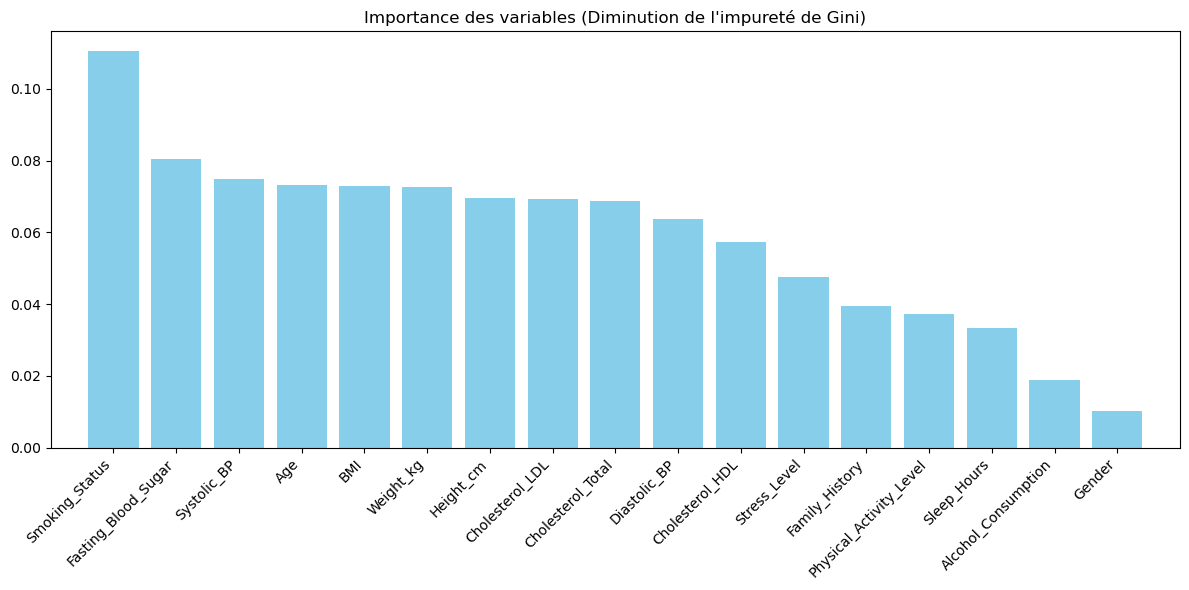

In [9]:


# Optimisation du paramètre max_features par validation croisée
# On teste de 2 à 8 variables tirées aléatoirement pour chaque nœud
param_rf = [{"max_features": list(range(2, 9, 1))}]

# On active oob_score=True comme dans le TP
forest = RandomForestClassifier(n_estimators=100, random_state=randomseed, oob_score=True)
rf = GridSearchCV(forest, param_rf, cv=5, n_jobs=-1)
rfOpt = rf.fit(X_train, y_train)

# Paramètre optimal
print("Meilleur score (Accuracy) = %f, Meilleur paramètre = %s" % (rfOpt.best_score_, rfOpt.best_params_))

# Récupération du meilleur modèle pour lire le score OOB
best_rf = rfOpt.best_estimator_
print("Erreur Out-Of-Bag (OOB) : %f" % (1 - best_rf.oob_score_))

# Erreur de prévision sur le test
print("Erreur de prévision sur le test : %f" % (1 - rfOpt.score(X_test, y_test)))

# Prévision et matrice de confusion
y_chap_rf = rfOpt.predict(X_test)
table_rf = pd.crosstab(y_chap_rf, y_test, rownames=['Prédit'], colnames=['Observé'])
print("\nMatrice de confusion Random Forest :\n", table_rf)

# --- Importance décroissante des variables (Codé exactement comme dans le TP) ---
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nImportance des variables :")
for f in range(X_train.shape[1]):
    print(X_train.columns[indices[f]], importances[indices[f]])

# Graphe des importances (Adapté du TP)
plt.figure(figsize=(12, 6))
plt.title("Importance des variables (Diminution de l'impureté de Gini)")
plt.bar(range(X_train.shape[1]), importances[indices], color="skyblue")
# On ajoute une rotation pour que les noms de tes variables soient lisibles
plt.xticks(range(X_train.shape[1]), X_train.columns[indices].tolist(), rotation=45, ha="right")
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout() # Évite que les labels soient coupés
plt.show()

1. La performance globale : La forêt fait mieux que l'arbre seul
L'exactitude (Accuracy) sur le test : Ton erreur de prévision est de 0.260, ce qui signifie que ton modèle a une précision d'environ 74%.

L'évolution : C'est une belle victoire pour la théorie ! Ton arbre optimal (CART) plafonnait à environ 73%. En combinant 100 arbres grâce à la Forêt Aléatoire, tu as réussi à corriger une partie de l'instabilité de l'arbre unique et à faire remonter ton score.

L'erreur OOB (0.283) : L'erreur calculée "à la volée" pendant l'apprentissage (OOB) était d'environ 28%. Elle est très proche de ton erreur réelle sur le test (26%). Cela prouve que ton modèle est robuste et qu'il ne fait pas de surapprentissage.

2. L'avantage médical : Moins de patients malades ratés (Matrice de confusion)
C'est ici que ton modèle brille le plus. Comparons les erreurs critiques (les Faux Négatifs, c'est-à-dire les malades déclarés sains) :

Avec l'arbre CART, tu avais 498 faux négatifs.

Avec la Forêt Aléatoire, tu n'as plus que 444 faux négatifs.

Interprétation : Ton nouveau modèle a "sauvé" 54 patients supplémentaires par rapport à l'arbre simple en les diagnostiquant correctement. En médecine, réduire ce chiffre est souvent plus important que d'avoir le score global le plus élevé.

3. La surprise des variables : Le mode de vie passe avant l'âge !
L'arbre de décision simple s'était focalisé presque uniquement sur l'Âge et la Pression artérielle. La Forêt Aléatoire nous donne une vision beaucoup plus riche (car elle force les arbres à regarder d'autres variables grâce au paramètre max_features: 3) :

Le top 2 absolu : Le Statut Tabagique (Smoking_Status) et la Glycémie à jeun (Fasting_Blood_Sugar) sont révélés comme les deux facteurs les plus déterminants pour ce modèle.

La conclusion biologique : Alors que l'arbre CART donnait l'impression que la maladie n'était qu'une question de vieillesse, la Forêt Aléatoire démontre que le mode de vie (le tabac) et le métabolisme (le sucre dans le sang) sont en réalité des déclencheurs majeurs du risque cardiovasculaire.

En une phrase de conclusion pour ta prof : « La Forêt Aléatoire a fait exactement ce qu'on attendait d'elle : elle a amélioré la précision globale par rapport à l'arbre seul, elle a réduit les erreurs de diagnostic dangereuses (faux négatifs), et elle a révélé l'importance cachée du tabac et de la glycémie dans la prédiction du risque. »